# ImageNet Object Ratio

Minimal version: one cumulative plot only.

- Uses full-image coverage rows only (`k = total / 3`).
- Sorts by `object ratio` from `fix_nonmask`.
- Uses three panels: `safe`, `unknown`, and `unsafe`.
- Each panel shows two curves only: `object` and `global`.


Using CSV: /Users/zd3504phd/Desktop/XAIV/results/vggnet16/ALL_vggnet.csv
Paired rows: 181
Final object safe count: 41
Final global safe count: 13


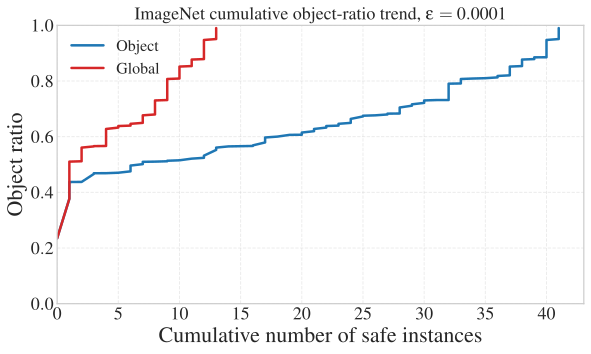

In [4]:
import os
import shutil
import subprocess
from pathlib import Path

CACHE_ROOT = Path.cwd() / ".cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

texlive_root = Path("/opt/homebrew/Cellar/texlive")
tex_bin_candidates = [
    Path("/opt/homebrew/opt/texlive/bin"),
    *sorted(texlive_root.glob("*/bin"), reverse=True),
    Path("/opt/homebrew/bin"),
    Path("/Library/TeX/texbin"),
    Path("/usr/texbin"),
]
tex_lib_candidates = [
    Path("/opt/homebrew/opt/libpng/lib"),
    Path("/opt/homebrew/opt/texlive/lib"),
    *sorted(texlive_root.glob("*/lib"), reverse=True),
]

current_path = os.environ.get("PATH", "")
path_parts = current_path.split(":") if current_path else []
for texbin in tex_bin_candidates:
    if texbin.exists():
        texbin_str = str(texbin)
        if texbin_str not in path_parts:
            path_parts.insert(0, texbin_str)
os.environ["PATH"] = ":".join(path_parts)

current_dyld = os.environ.get("DYLD_LIBRARY_PATH", "")
dyld_parts = current_dyld.split(":") if current_dyld else []
for texlib in tex_lib_candidates:
    if texlib.exists():
        texlib_str = str(texlib)
        if texlib_str not in dyld_parts:
            dyld_parts.insert(0, texlib_str)
if dyld_parts:
    os.environ["DYLD_LIBRARY_PATH"] = ":".join(dyld_parts)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
except ImportError:
    set_matplotlib_formats = None

FORCE_TEX = True


def latex_ready():
    has_renderer = shutil.which("dvipng") is not None or shutil.which("dvisvgm") is not None
    return shutil.which("latex") is not None and has_renderer


def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0


def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if set_matplotlib_formats is not None:
        if use_tex and shutil.which("dvisvgm") is not None:
            set_matplotlib_formats("svg")
        else:
            set_matplotlib_formats("png")

    if force_tex and not use_tex:
        print("LaTeX was requested but no compatible renderer was found. Falling back to Matplotlib serif text.")

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "text.latex.preamble": preamble,
        "font.size": 16,
        "axes.labelsize": 22,
        "axes.titlesize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex


use_tex = configure_plot_style()

CSV_CANDIDATES = [
    Path.cwd() / "../../results/vggnet16/ALL_vggnet.csv",
    Path.cwd() / "csvs/ALL_vggnet_triplets_merged.csv",
    Path.cwd() / "../../analysis/csvs/ALL_vggnet_triplets_merged.csv",
]

for candidate in CSV_CANDIDATES:
    candidate = candidate.resolve()
    if candidate.exists():
        CSV_PATH = candidate
        break
else:
    checked = "\n".join(str(path.resolve()) for path in CSV_CANDIDATES)
    raise FileNotFoundError(f"Could not find the ImageNet CSV. Checked:\n{checked}")

df = pd.read_csv(CSV_PATH)

for col in ["eps", "k", "total", "segment_index", "num_changed"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["tag", "image", "model"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df = df.dropna(subset=["total", "k", "num_changed"]).copy()
df = df[df["tag"].isin(["fix_nonmask", "global"])].copy()
df = df[df["total"].astype(int) == 150528].copy()
df["full_k"] = (df["total"] // 3).astype(int)
df = df[df["k"].astype(int) == df["full_k"]].copy()


def canon_result(value):
    text = str(value).lower()
    if "unsat" in text:
        return "safe"
    if "sat" in text:
        return "unsafe"
    return "unknown"


df["result_cat"] = df["result"].apply(canon_result)

key_global = [col for col in ["model", "image", "eps", "k", "total"] if col in df.columns]
key_object = [col for col in ["model", "image", "segment_index", "eps", "k", "total"] if col in df.columns]

object_df = (
    df[df["tag"] == "fix_nonmask"][key_object + ["num_changed", "result_cat"]]
    .rename(columns={"num_changed": "obj_changed", "result_cat": "obj_result"})
    .copy()
)

global_df = (
    df[df["tag"] == "global"][key_global + ["result_cat"]]
    .rename(columns={"result_cat": "glb_result"})
    .drop_duplicates(subset=key_global, keep="first")
    .copy()
)

paired = object_df.merge(global_df, on=key_global, how="left")
paired = paired.dropna(subset=["glb_result"]).copy()

if paired.empty:
    raise ValueError("No paired object/global rows found after filtering.")

paired["object_ratio"] = paired["obj_changed"] / paired["total"]
paired = paired.sort_values("object_ratio").reset_index(drop=True)


def cumulative_count(series, label):
    hits = (series == label).astype(int).to_numpy()
    return hits.cumsum()


x = paired["object_ratio"].to_numpy()
result_order = ["safe", "unknown", "unsafe"]
method_colors = {"Object": "#1f77b4", "Global": "#d62728"}

curves = {
    "Object": {label: cumulative_count(paired["obj_result"], label) for label in result_order},
    "Global": {label: cumulative_count(paired["glb_result"], label) for label in result_order},
}

eps_values = paired["eps"].dropna().unique()
eps_text = rf", $\epsilon={eps_values[0]:g}$" if len(eps_values) == 1 else ""

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16.8, 4.8),
    sharey=True,
)

max_count = max(curve.max() for method_curves in curves.values() for curve in method_curves.values())

for ax, label in zip(axes, result_order):
    for method, color in method_colors.items():
        ax.plot(
            curves[method][label],
            x,
            linewidth=2.5,
            color=color,
            label=method,
        )

    ax.set_xlim(0, max_count * 1.05)
    ax.set_ylim(0, 1)
    ax.set_title(label.capitalize(), fontsize=16, pad=8)
    ax.tick_params(axis="both", labelsize=15)
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle(f"ImageNet cumulative object-ratio trend{eps_text}", y=0.98)
fig.supxlabel("Cumulative count", y=0.08, fontsize=18)
fig.supylabel("Object ratio", x=0.04, fontsize=18)
handles = [
    mpl.lines.Line2D([0], [0], color=color, linewidth=2.5, linestyle="-", label=method)
    for method, color in method_colors.items()
]
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.91),
    fontsize=15,
    handlelength=2.8,
    columnspacing=1.8,
)
fig.subplots_adjust(top=0.78, bottom=0.22, left=0.08, right=0.98, wspace=0.12)

print(f"Using CSV: {CSV_PATH}")
print(f"Paired rows: {len(paired)}")
for method in ["Object", "Global"]:
    counts = {label: int(curves[method][label][-1]) for label in result_order}
    print(f"Final {method.lower()} counts: {counts}")

# Optional save:
# fig.savefig("object_ratio_imagenet_cumulative.pdf", bbox_inches="tight")

plt.show()
